In [1]:
import os
import pandas as pd

In [2]:
DATA_PATH = "gym_membership_churn.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Place the generated dataset `gym_membership.csv` in the notebook folder. Expected path: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Loaded", len(df), "rows")

display(df.head())

Loaded 5000 rows


,gender,age,visits_per_week,visits_last_7d,visits_last_4w,visits_prev_4w,days_since_last_visit,membership_price,membership_duration_days,membership_days_to_expire,churn
0,Female,35,2,1,7,4,0,9990,180,174,1
1,Female,22,2,0,7,7,15,5490,90,45,1
2,Female,36,2,4,9,12,0,5490,90,13,0
3,Female,29,2,1,5,10,2,5490,90,75,0
4,Female,26,2,1,6,7,1,2990,30,-1,0


In [3]:
df['engagement_score'] = (
    df.get('visits_last_4w', 0) * 0.6 +
    df.get('visits_prev_4w', 0) * 0.3 -
    df['days_since_last_visit'].fillna(0) * 0.1
)

TARGET = 'churn'
if TARGET not in df.columns:
    raise ValueError('churn column not found')

In [4]:
FEATURES = df.columns.copy().drop(TARGET)

cat_features = [c for c in ['gender','membership_type'] if c in df.columns]
num_features = [c for c in FEATURES if c not in cat_features]

print("Using features:", len(FEATURES))
print(FEATURES)

Using features: 11
Index(['gender', 'age', 'visits_per_week', 'visits_last_7d', 'visits_last_4w',
       'visits_prev_4w', 'days_since_last_visit', 'membership_price',
       'membership_duration_days', 'membership_days_to_expire',
       'engagement_score'],
      dtype='str')


In [5]:
from sklearn.model_selection import train_test_split

X = df[FEATURES].copy()
y = df[TARGET].copy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
print('Random stratified split sizes:', X_train.shape, X_test.shape)

Random stratified split sizes: (4000, 11) (1000, 11)


In [6]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

model = CatBoostClassifier(
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    loss_function='Logloss',
    class_weights=[1,2],
    verbose=100,
    early_stopping_rounds=100
)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

y_pred = model.predict(test_pool)
y_pred_proba = model.predict_proba(test_pool)[:,1]

0:	test: 0.7634017	best: 0.7634017 (0)	total: 58.8ms	remaining: 58.7s
100:	test: 0.7958663	best: 0.7966434 (93)	total: 176ms	remaining: 1.57s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7966434042
bestIteration = 93

Shrink model to first 94 iterations.


In [7]:
import os

os.makedirs("models", exist_ok=True)
model.save_model("../models/catboost_model.cbm")

## Графики

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

Accuracy: 0.809
ROC-AUC: 0.7966434041501976
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       736
           1       0.72      0.45      0.55       264

    accuracy                           0.81      1000
   macro avg       0.77      0.69      0.72      1000
weighted avg       0.80      0.81      0.79      1000



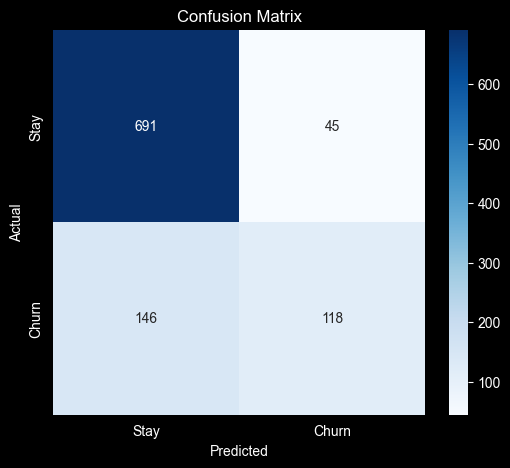

In [9]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", auc)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stay','Churn'],
    yticklabels=['Stay','Churn']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

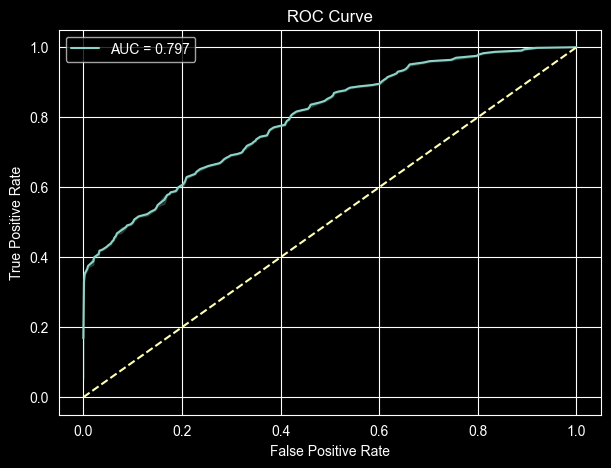

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7,5))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

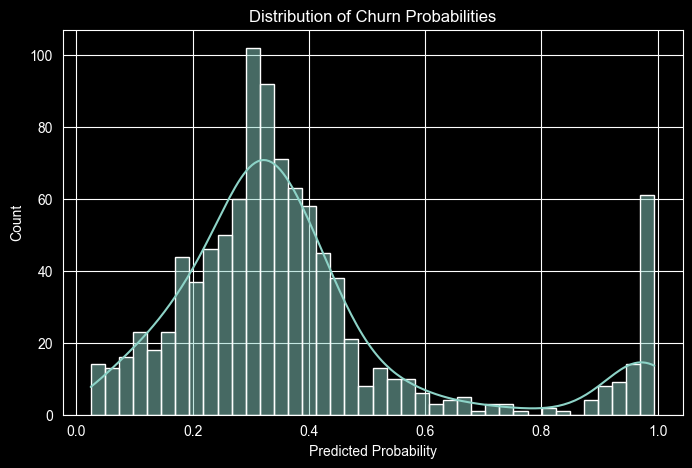

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    y_pred_proba,
    bins=40,
    kde=True
)

plt.title("Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability")
plt.show()

/Users/ultar/PycharmProjects/ZPassFitAI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


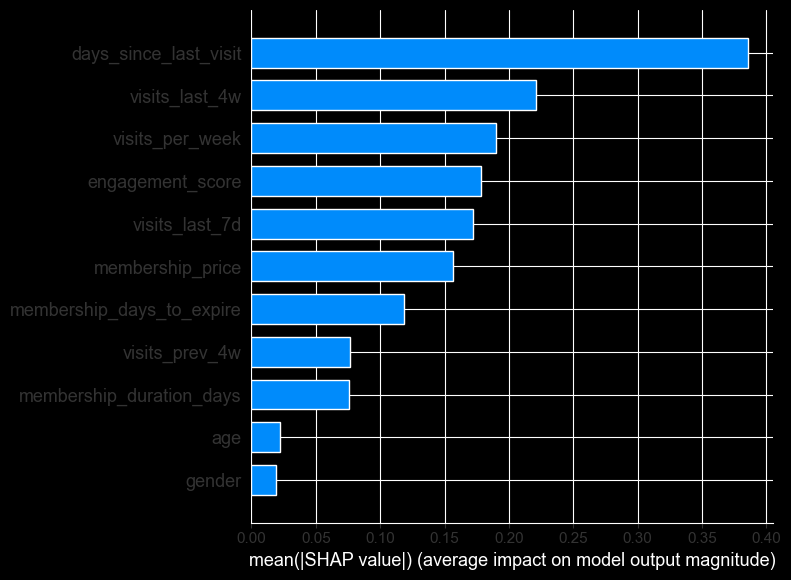

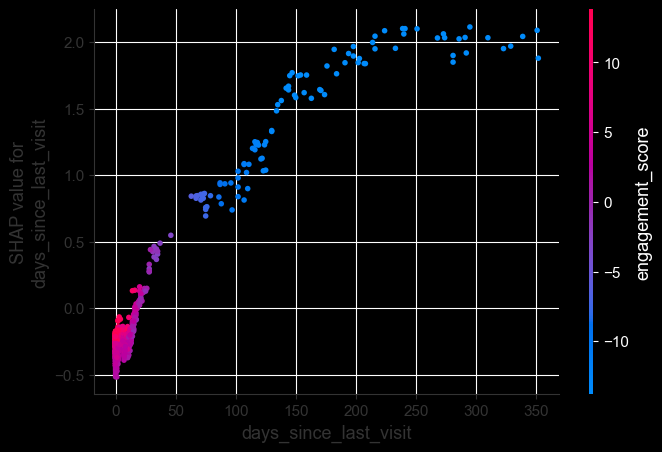

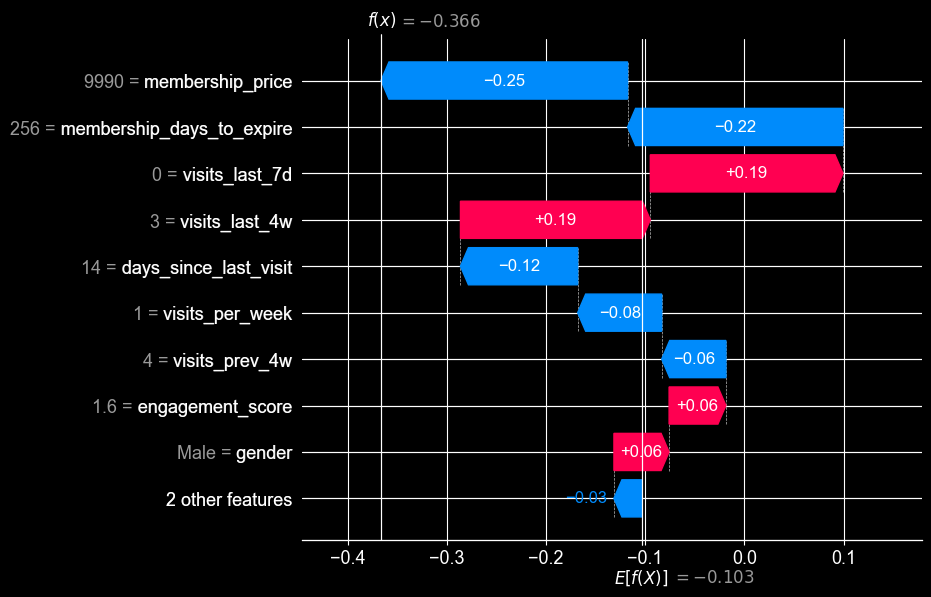

In [12]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

shap.dependence_plot(
    "days_since_last_visit",
    shap_values,
    X_test
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)